<a href="https://colab.research.google.com/github/stopstoptalking/114_2_Seminar_Abstract_Checker/blob/main/115_1_EngMath_5E_Hologram_Lab_v2_%E5%AD%B8%E7%94%9F%E7%89%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 工程數學 II ｜ 單元 1 ：向量、行空間與 Rank
## 5E 探究式學習 × 3D 全息金字塔投影  互動實作本

---

### 這份 Notebook 怎麼用

**每位同學自己開一份副本、自己執行、產生自己的手機網頁。**（檔案 → 在雲端硬碟中儲存副本）

| 區段 | 內容 | 對應課堂時間 |
|---|---|---|
| **第 1 – 5 步** | 一次性設定：安裝 → 引擎 → 校正圖 → **你自己的手機網頁 + QR** → 依螢幕調參數 | 課前 10 分鐘 |
| **Session 0** | 熱身：輸入你的第一個向量，變成全息投影 | 課前 |
| **Phase 1 Engage** | 無人機兩顆推進器、目標點 **b** 可達性 | 00:00 – 00:30 |
| **Phase 2 Explore** | 滑桿線性組合、500 點雲平面、第 3 向量與行消去法 | 00:30 – 01:15 |
| **Phase 3 Explain** | Column Space / Rank 正式定義、Column View vs Row View | 01:15 – 01:55 |
| **Phase 4 Elaborate** | 印刷機色域盲區破案 | 01:55 – 02:35 |
| **Phase 5 Evaluate** | 相依向量被壓扁的旋轉展示 | 02:35 – 03:00 |

**每一段都是同一個流程：**

> `① 改參數` → `② 在 Colab 裡用滑鼠旋轉 3D 圖` → `③ 產生金字塔投影檔` → `④ push 自動更新到你的手機`

### 開始前

1. 依序執行 **第 1 ~ 5 步**（每一步各執行一次）。之後任何一格都能單獨重跑。
2. 用**自己的手機**掃**第 4 步產生的 QR Code**——那是你個人專屬的網頁。
3. 手機：螢幕亮度調到最大、關閉自動旋轉與螢幕休眠，金字塔放在畫面正中央。


In [1]:
#@title 【第 1 步 / 執行一次】安裝套件（約 40 秒） { display-mode: "form" }
!pip -q install imageio-ffmpeg qrcode[pil] gradio 2>/dev/null
import IPython, sys
print("套件安裝完成。Python", sys.version.split()[0])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.6 MB/s eta 0:00:00
套件安裝完成。Python 3.13.15


In [2]:
#@title 【第 2 步 / 執行一次】核心引擎：全息渲染 + Scene 場景物件（內容不用看，點左邊三角形可展開） { display-mode: "form" }
# ======================================================================
#  holo_core — 工程數學 II 全息金字塔核心引擎
#  (單元 1：向量、行空間、Rank)
# ======================================================================
import inspect, io, os, math
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# ---------------- 黑底高對比亮色 ----------------
CYAN    = "#00E5FF"
MAGENTA = "#FF3DDC"
YELLOW  = "#FFE94A"
GREEN   = "#5CFF7A"
ORANGE  = "#FF9A3C"
RED     = "#FF5555"
WHITE   = "#FFFFFF"
GREY    = "#9AA0A6"

OUT_DIR = "holo_out"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------- 全域校正參數（現場實測後改這裡） ----------------
CFG = dict(
    canvas_px = 1080,   # 輸出正方形畫布邊長
    view_px   = 420,    # 單一視角邊長
    offset    = 270,    # 視角中心離畫布中心的距離 → 要對應金字塔實際尺寸
    elev      = 15,     # 相機仰角，金字塔是水平看進去的，建議 10~20
    azim_front= 90,     # 正面視角（下方格）的方位角
    zoom      = 1.35,   # 物件在格子裡的放大倍率，被切到就調小
    mirror    = True,   # 預先左右翻轉以抵銷鏡面反射
    grid      = True,   # 對齊格線（中央十字 + 四邊方框 + 對角線）
    grid_level= 55,     # 格線亮度 0~255。校正時可調到 120，上課時調低
    fps       = 20,
)

# 排版表：slot -> (rot90 次數(逆時針), 方位角偏移, (dy, dx))
_SLOTS = {
    "bottom": (0,   0, ( 1,  0)),
    "left":   (3, -90, ( 0, -1)),
    "top":    (2, 180, (-1,  0)),
    "right":  (1,  90, ( 0,  1)),
}
_FACE = {"bottom": "FRONT", "left": "RIGHT", "top": "BACK", "right": "LEFT"}


def _wants_view(fn):
    try:
        return len(inspect.signature(fn).parameters) >= 3
    except (TypeError, ValueError):
        return False


def _render_view(draw_fn, t, azim, elev, lim, view_px, dpi, zoom, view):
    fig = plt.figure(figsize=(view_px / dpi, view_px / dpi), dpi=dpi)
    fig.patch.set_facecolor("black")
    ax = fig.add_subplot(111, projection="3d")
    ax.set_facecolor("black")
    try:
        if _wants_view(draw_fn):
            draw_fn(ax, t, view)
        else:
            draw_fn(ax, t)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
        ax.set_box_aspect((1, 1, 1), zoom=zoom)
        ax.set_axis_off()
        ax.view_init(elev=elev, azim=azim)
        fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
        fig.canvas.draw()
        img = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    finally:
        plt.close(fig)
    return img


def _paste_max(canvas, img, cy, cx):
    h, w, _ = img.shape
    y0, x0 = cy - h // 2, cx - w // 2
    y1, x1 = y0 + h, x0 + w
    sy0, sx0 = max(0, -y0), max(0, -x0)
    y0, x0 = max(0, y0), max(0, x0)
    y1, x1 = min(canvas.shape[0], y1), min(canvas.shape[1], x1)
    if y1 <= y0 or x1 <= x0:
        return
    sub = img[sy0:sy0 + (y1 - y0), sx0:sx0 + (x1 - x0)]
    canvas[y0:y1, x0:x1] = np.maximum(canvas[y0:y1, x0:x1], sub)


# ----------------------------------------------------------------------
#  對齊格線：中央十字 + 四邊方框（金字塔底座輪廓）+ 對角線 + 邊中點標記
# ----------------------------------------------------------------------
def _line(canvas, p0, p1, val, w=1):
    """在畫布上畫一條線（只畫水平/垂直/45度，夠用且不需要額外相依）。"""
    y0, x0 = p0; y1, x1 = p1
    n = int(max(abs(y1 - y0), abs(x1 - x0))) + 1
    ys = np.linspace(y0, y1, n).round().astype(int)
    xs = np.linspace(x0, x1, n).round().astype(int)
    H, W, _ = canvas.shape
    for dy in range(-(w // 2), w // 2 + 1):
        for dx in range(-(w // 2), w // 2 + 1):
            yy = np.clip(ys + dy, 0, H - 1); xx = np.clip(xs + dx, 0, W - 1)
            canvas[yy, xx] = np.maximum(canvas[yy, xx], val)


def _draw_align_grid(canvas, offset, view_px, level=55):
    """
    畫對齊格線。用途：
      - 中央十字 + 中心小方塊：把金字塔頂點對準畫布正中心
      - 四邊方框：金字塔底座四條邊應該剛好壓在方框上
      - 四條對角線：金字塔四條稜線的位置
      - 邊中點的粗標記：快速目視確認沒有歪斜
    """
    N = canvas.shape[0]
    c = N // 2
    R = offset + view_px // 2          # 底座半邊長（= 每格外緣）
    R = min(R, c - 2)
    v_dim  = np.array([level, level, level], dtype=np.uint8)
    v_mid  = np.array([level + 45, level + 45, level + 45], dtype=np.uint8)
    v_hot  = np.array([min(255, level + 110)] * 3, dtype=np.uint8)

    # 1) 中央十字（貫穿全畫布）
    _line(canvas, (c, 0), (c, N - 1), v_dim, 1)
    _line(canvas, (0, c), (N - 1, c), v_dim, 1)

    # 2) 四邊方框 = 金字塔底座輪廓
    _line(canvas, (c - R, c - R), (c - R, c + R), v_mid, 2)
    _line(canvas, (c + R, c - R), (c + R, c + R), v_mid, 2)
    _line(canvas, (c - R, c - R), (c + R, c - R), v_mid, 2)
    _line(canvas, (c - R, c + R), (c + R, c + R), v_mid, 2)

    # 3) 四條對角線（中心 → 底座四角）＝ 金字塔稜線投影
    for sy in (-1, 1):
        for sx in (-1, 1):
            _line(canvas, (c, c), (c + sy * R, c + sx * R), v_dim, 1)

    # 4) 邊中點粗標記（每條邊中央往內 24px 的短線）
    m = max(18, R // 10)
    _line(canvas, (c - R, c - m), (c - R, c + m), v_hot, 3)
    _line(canvas, (c + R, c - m), (c + R, c + m), v_hot, 3)
    _line(canvas, (c - m, c - R), (c + m, c - R), v_hot, 3)
    _line(canvas, (c - m, c + R), (c + m, c + R), v_hot, 3)

    # 5) 中心小方塊（金字塔頂點對位用）
    s = max(10, R // 22)
    _line(canvas, (c - s, c - s), (c - s, c + s), v_hot, 2)
    _line(canvas, (c + s, c - s), (c + s, c + s), v_hot, 2)
    _line(canvas, (c - s, c - s), (c + s, c - s), v_hot, 2)
    _line(canvas, (c - s, c + s), (c + s, c + s), v_hot, 2)
    return canvas


def _compose_frame(draw_fn, t, *, azim_front, elev, lim, view_px,
                   canvas_px, offset, dpi, mirror, zoom, grid, grid_level,
                   spin=0.0):
    canvas = np.zeros((canvas_px, canvas_px, 3), dtype=np.uint8)
    c = canvas_px // 2
    for slot, (k, dazim, (dy, dx)) in _SLOTS.items():
        azim = azim_front + dazim + spin * t
        view = {"slot": slot, "azim": azim, "elev": elev, "face": _FACE[slot]}
        img = _render_view(draw_fn, t, azim, elev, lim, view_px, dpi, zoom, view)
        if mirror:
            img = img[:, ::-1]
        img = np.rot90(img, k)
        _paste_max(canvas, np.ascontiguousarray(img),
                   c + dy * offset, c + dx * offset)
    if grid:
        _draw_align_grid(canvas, offset, view_px, grid_level)
    return canvas


def render_hologram(draw_fn, out_path, *, n_frames=1, lim=1.2,
                    loop_back=False, dpi=100, spin=0.0, **over):
    """
    把 draw_fn(ax, t) 渲染成金字塔全息投影用的 PNG / MP4。

    draw_fn  : callable(ax, t) 或 callable(ax, t, view)。只負責畫內容。
    n_frames : 1 → PNG；>1 → MP4。
    lim      : 座標範圍 ±lim。
    spin     : 整段影片相機繞行的總角度（度）。360 = 物件自轉一圈。
    其餘關鍵字會覆寫 CFG（offset / zoom / elev / grid / grid_level ...）。
    """
    p = dict(CFG); p.update(over)
    out_path = out_path if os.path.dirname(out_path) else os.path.join(OUT_DIR, out_path)
    kw = dict(azim_front=p["azim_front"], elev=p["elev"], lim=lim,
              view_px=p["view_px"], canvas_px=p["canvas_px"], offset=p["offset"],
              dpi=dpi, mirror=p["mirror"], zoom=p["zoom"],
              grid=p["grid"], grid_level=p["grid_level"], spin=spin)
    if n_frames == 1:
        imageio.imwrite(out_path, _compose_frame(draw_fn, 0.0, **kw))
        print(f"[ok] {out_path}  ({p['canvas_px']}x{p['canvas_px']} 靜態圖)")
        return out_path
    frames = [_compose_frame(draw_fn, i / n_frames, **kw) for i in range(n_frames)]
    if loop_back:
        frames = frames + frames[-2:0:-1]
    if out_path.lower().endswith(".gif"):
        imageio.mimsave(out_path, frames, fps=p["fps"], loop=0)
    else:
        imageio.mimsave(out_path, frames, fps=p["fps"], codec="libx264",
                        quality=8, macro_block_size=1)
    print(f"[ok] {out_path}  ({len(frames)} 影格 @ {p['fps']}fps)")
    return out_path


# ======================================================================
#  Scene：一份場景描述，同時供 (a) Colab 互動 3D 預覽 (b) 全息渲染
# ======================================================================
class Scene:
    def __init__(self, lim=None, axes=True):
        self.axes = axes            # True = 全息圖上畫出 x/y/z 三軸（與 3D 預覽一致）
        self.arrows, self.points, self.clouds = [], [], []
        self.grids, self.lines = [], []
        self._lim = lim

    # ---- 建構 API ----
    def arrow(self, vec, color=CYAN, label=None, origin=(0, 0, 0), width=4):
        self.arrows.append(dict(o=np.asarray(origin, float),
                                v=np.asarray(vec, float),
                                color=color, label=label, width=width))
        return self

    def point(self, p, color=WHITE, label=None, size=9):
        self.points.append(dict(p=np.asarray(p, float), color=color,
                                label=label, size=size))
        return self

    def cloud(self, pts, color=CYAN, size=2, opacity=0.55):
        self.clouds.append(dict(pts=np.asarray(pts, float), color=color,
                                size=size, opacity=opacity))
        return self

    def span_plane(self, v1, v2, color=CYAN, rng=1.2, n=9, alpha=0.7):
        """畫出 span{v1, v2}（通過原點的平面）的網格線。"""
        self.grids.append(dict(v1=np.asarray(v1, float), v2=np.asarray(v2, float),
                               color=color, rng=rng, n=n, alpha=alpha))
        return self

    def plane_eq(self, normal, d, color=CYAN, rng=1.2, n=7, alpha=0.6):
        """畫平面 n·x = d 的網格線。"""
        nv = np.asarray(normal, float)
        nn = nv / np.linalg.norm(nv)
        p0 = (d / np.dot(nv, nv)) * nv
        tmp = np.array([1.0, 0, 0]) if abs(nn[0]) < 0.9 else np.array([0, 1.0, 0])
        u = np.cross(nn, tmp); u /= np.linalg.norm(u)
        v = np.cross(nn, u)
        self.grids.append(dict(v1=u, v2=v, origin=p0, color=color,
                               rng=rng, n=n, alpha=alpha))
        return self

    def polyline(self, pts, color=WHITE, width=2, dashed=False):
        self.lines.append(dict(pts=np.asarray(pts, float), color=color,
                               width=width, dashed=dashed))
        return self

    # ---- 自動座標範圍 ----
    @property
    def lim(self):
        if self._lim:
            return self._lim
        m = 1.0
        for a in self.arrows:
            m = max(m, np.abs(a["o"] + a["v"]).max())
        for p in self.points:
            m = max(m, np.abs(p["p"]).max())
        for c in self.clouds:
            m = max(m, np.abs(c["pts"]).max()) if len(c["pts"]) else m
        for l in self.lines:
            m = max(m, np.abs(l["pts"]).max())
        return float(m) * 1.15

    # ---- (a) matplotlib：給全息引擎用 ----
    def draw(self, ax, t=0.0):
        L = self.lim
        if getattr(self, "axes", True):
            A = L * 0.92
            for v, lab in [((1, 0, 0), "x"), ((0, 1, 0), "y"), ((0, 0, 1), "z")]:
                d = np.array(v, float) * A
                ax.plot([-d[0], 0], [-d[1], 0], [-d[2], 0],
                        color="#4A5560", linewidth=1.0, alpha=0.65)   # 負半軸（暗）
                ax.quiver(0, 0, 0, *d, color="#8A97A5", linewidth=1.3,
                          arrow_length_ratio=0.05)                     # 正半軸（含箭頭）
                ax.text(*(d * 1.10), lab, color="#C9D2DC", fontsize=12)
        for g in self.grids:
            o = g.get("origin", np.zeros(3))
            v1, v2 = g["v1"], g["v2"]
            v1 = v1 / np.linalg.norm(v1); v2 = v2 / np.linalg.norm(v2)
            R = g["rng"] * L * 0.5
            s = np.linspace(-R, R, g["n"])
            for k in s:
                for e in (np.array([o + k * v1 - R * v2, o + k * v1 + R * v2]),
                          np.array([o + k * v2 - R * v1, o + k * v2 + R * v1])):
                    ax.plot(e[:, 0], e[:, 1], e[:, 2], color=g["color"],
                            linewidth=0.8, alpha=g["alpha"])
        for c in self.clouds:
            P = c["pts"]
            if len(P):
                ax.scatter(P[:, 0], P[:, 1], P[:, 2], color=c["color"],
                           s=c["size"] * 2, alpha=c["opacity"], depthshade=False,
                           edgecolors="none")
        for l in self.lines:
            P = l["pts"]
            ax.plot(P[:, 0], P[:, 1], P[:, 2], color=l["color"],
                    linewidth=l["width"], linestyle="--" if l["dashed"] else "-")
        for a in self.arrows:
            ax.quiver(*a["o"], *a["v"], color=a["color"], linewidth=a["width"],
                      arrow_length_ratio=0.16)
            if a["label"]:
                tip = a["o"] + a["v"] * 1.1
                ax.text(*tip, a["label"], color=a["color"], fontsize=11)
        for p in self.points:
            ax.scatter(*p["p"], color=p["color"], s=p["size"] * 22,
                       depthshade=False, edgecolors="none")
            if p["label"]:
                ax.text(*(p["p"] + 0.08 * L), p["label"], color=p["color"], fontsize=11)

    def draw_fn(self):
        return lambda ax, t: self.draw(ax, t)

    # ---- (b) Plotly：Colab 內可旋轉的互動預覽 ----
    def figure(self, title="", height=560):
        import plotly.graph_objects as go
        L = self.lim
        data = []
        for g in self.grids:
            o = g.get("origin", np.zeros(3))
            v1 = g["v1"] / np.linalg.norm(g["v1"])
            v2 = g["v2"] / np.linalg.norm(g["v2"])
            R = g["rng"] * L * 0.5
            s = np.linspace(-R, R, g["n"])
            X, Y, Z = [], [], []
            for k in s:
                for e in ((o + k * v1 - R * v2, o + k * v1 + R * v2),
                          (o + k * v2 - R * v1, o + k * v2 + R * v1)):
                    X += [e[0][0], e[1][0], None]
                    Y += [e[0][1], e[1][1], None]
                    Z += [e[0][2], e[1][2], None]
            data.append(go.Scatter3d(x=X, y=Y, z=Z, mode="lines",
                                     line=dict(color=g["color"], width=2),
                                     opacity=g["alpha"], hoverinfo="skip",
                                     showlegend=False))
        for c in self.clouds:
            P = c["pts"]
            if len(P):
                data.append(go.Scatter3d(x=P[:, 0], y=P[:, 1], z=P[:, 2],
                                         mode="markers", showlegend=False,
                                         marker=dict(size=c["size"], color=c["color"],
                                                     opacity=c["opacity"])))
        for l in self.lines:
            P = l["pts"]
            data.append(go.Scatter3d(x=P[:, 0], y=P[:, 1], z=P[:, 2], mode="lines",
                                     line=dict(color=l["color"], width=l["width"],
                                               dash="dash" if l["dashed"] else "solid"),
                                     showlegend=False))
        for a in self.arrows:
            o, v = a["o"], a["v"]
            tip = o + v
            data.append(go.Scatter3d(x=[o[0], tip[0]], y=[o[1], tip[1]],
                                     z=[o[2], tip[2]], mode="lines",
                                     line=dict(color=a["color"], width=a["width"] + 2),
                                     name=a["label"] or "", showlegend=bool(a["label"])))
            n = np.linalg.norm(v)
            if n > 1e-9:
                data.append(go.Cone(x=[tip[0]], y=[tip[1]], z=[tip[2]],
                                    u=[v[0] / n], v=[v[1] / n], w=[v[2] / n],
                                    sizemode="absolute", sizeref=0.12 * L,
                                    anchor="tip", showscale=False,
                                    colorscale=[[0, a["color"]], [1, a["color"]]]))
        for p in self.points:
            data.append(go.Scatter3d(x=[p["p"][0]], y=[p["p"][1]], z=[p["p"][2]],
                                     mode="markers+text",
                                     marker=dict(size=p["size"], color=p["color"]),
                                     text=[p["label"] or ""], textposition="top center",
                                     textfont=dict(color=p["color"]),
                                     showlegend=False))
        ax = lambda t: dict(title=t, range=[-L, L], backgroundcolor="rgb(12,12,16)",
                            gridcolor="rgb(60,60,70)", zerolinecolor="rgb(120,120,140)")
        fig = go.Figure(data=data)
        fig.update_layout(title=title, height=height, template="plotly_dark",
                          margin=dict(l=0, r=0, t=40, b=0),
                          scene=dict(xaxis=ax("x"), yaxis=ax("y"), zaxis=ax("z"),
                                     aspectmode="cube"))
        return fig

    def show(self, title=""):
        self.figure(title).show()
        return self

    # ---- 一鍵輸出全息圖 ----
    def to_hologram(self, filename, spin=0, n_frames=72, **kw):
        """spin=0 → 靜態 PNG；spin=360 → 相機繞物件一圈的 MP4。"""
        if spin:
            return render_hologram(self.draw_fn(), filename, n_frames=n_frames,
                                   lim=self.lim, spin=spin, loop_back=False, **kw)
        return render_hologram(self.draw_fn(), filename, lim=self.lim, **kw)


def animate_hologram(scene_fn, filename, n_frames=60, spin=0, loop_back=True, **kw):
    """
    scene_fn(t) -> Scene，t 由 0 跑到 1。用於「係數變化」類的動畫。
    """
    sc0 = scene_fn(0.0)
    lim = kw.pop("lim", sc0.lim)
    def df(ax, t):
        scene_fn(t).draw(ax, t)
    return render_hologram(df, filename, n_frames=n_frames, lim=lim,
                           spin=spin, loop_back=loop_back, **kw)


# ======================================================================
#  Colab 顯示小工具
# ======================================================================
from IPython.display import display, Image as IPImage, Video, HTML, FileLink

def show_png(path, width=520):
    """在 Colab 裡預覽金字塔投影圖。"""
    display(IPImage(filename=path, width=width))
    print(f"檔案：{path}   ← 左側『檔案』面板可下載，或用下方 Web 介面推到手機")

def play(path, width=480):
    """在 Colab 裡播放金字塔投影影片。"""
    display(Video(path, width=width, embed=True))
    print(f"檔案：{path}")

print("核心引擎載入完成。")
print("可用顏色：CYAN / MAGENTA / YELLOW / GREEN / ORANGE / RED / WHITE")
print("目前校正參數 CFG：")
for k, v in CFG.items():
    print(f"   {k:<11} = {v}")

核心引擎載入完成。
可用顏色：CYAN / MAGENTA / YELLOW / GREEN / ORANGE / RED / WHITE
目前校正參數 CFG：
   canvas_px   = 1080
   view_px     = 420
   offset      = 270
   elev        = 15
   azim_front  = 90
   zoom        = 1.35
   mirror      = True
   grid        = True
   grid_level  = 55
   fps         = 20


[ok] holo_out/S0_calibration.png  (1080x1080 靜態圖)


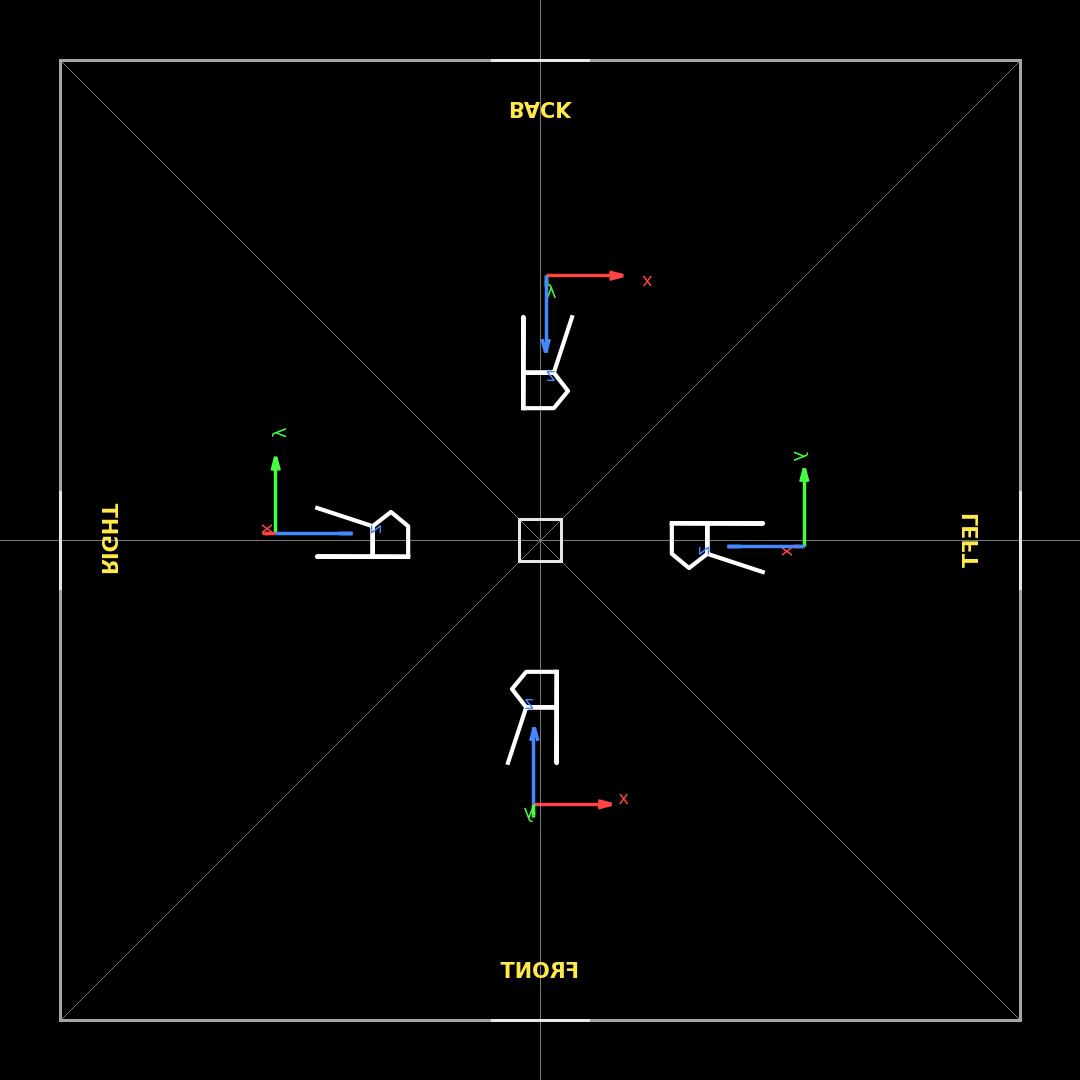

檔案：holo_out/S0_calibration.png   ← 左側『檔案』面板可下載，或用下方 Web 介面推到手機


In [3]:
#@title 【第 3 步 / 執行一次】校正圖：確認左右沒有顛倒、四面順序正確 { display-mode: "form" }
#  這格先在 Colab 裡看；第 5 步會把它推到你的手機上做對齊。
def draw_calibration(ax, t, view):
    """
    投影後繞著金字塔走一圈，確認三件事：
      1. 正面看到的字母 R 是「正的」    → 反了就把 CFG['mirror'] 改成 False
      2. 順時針依序讀到 FRONT → RIGHT → BACK → LEFT
                                      → 順序反了就把 CFG['azim_front'] ±90
      3. 中央三軸箭頭在四面之間是連續轉動、不會跳動
    注意：在螢幕上看這張圖，所有字都是反的 —— 這是對的，實體反射會轉回來。
    """
    for vec, col, lab in [((1, 0, 0), "#FF4444", "x"),
                          ((0, 1, 0), "#44FF44", "y"),
                          ((0, 0, 1), "#4488FF", "z")]:
        ax.quiver(0, 0, 0, *(0.55 * np.array(vec)), color=col,
                  linewidth=2.5, arrow_length_ratio=0.18)
        ax.text(*(0.68 * np.array(vec)), lab, color=col, fontsize=13)

    glyph = [(-.22, .45), (-.22, -.45), (-.22, .45), (.08, .45), (.22, .28),
             (.08, .10), (-.22, .10), (.08, .10), (.26, -.45)]
    phi = np.radians(view["azim"])
    right = np.array([-np.sin(phi), np.cos(phi), 0.0])
    up = np.array([0.0, 0.0, 1.0])
    base = np.array([np.cos(phi), np.sin(phi), 0.0]) * -0.7
    pts = np.array([base + 0.75 * u * right + (0.75 * v + 0.55) * up
                    for u, v in glyph])
    ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], color=WHITE, linewidth=3)
    ax.text2D(0.5, 0.10, view["face"], transform=ax.transAxes,
              color=YELLOW, fontsize=15, ha="center", weight="bold")

# 校正時把格線調亮一點比較好對齊
path = render_hologram(draw_calibration, "S0_calibration.png",
                       lim=1.2, elev=8, grid_level=120)
show_png(path)

---
## 第 4 步 ｜ 產生「你自己的」手機網頁 + QR Code

這份 Notebook 是**每位同學自己開一份副本、自己執行**的。跑下面那一格，
Colab 會為你開一個**臨時公開網址**並顯示 QR Code —— 這個網址只連到
**你這份 Colab 的 `holo_out/` 資料夾**，跟其他同學互不相干，也不需要老師傳檔案。

用**自己的手機**掃**自己的 QR Code**，會打開一個全螢幕純黑的四分屏頁面。

> **最精簡的版本其實只要 3 行**（想了解原理可以看這個）：
> ```python
> import gradio as gr
> gr.Interface(lambda f: f, gr.Dropdown(sorted(os.listdir(OUT_DIR))),
>              gr.Image()).launch(share=True)
> ```
> 下面那一格是加上「純黑全螢幕 + 影片支援 + 自動更新（push）+ QR Code」的完整版。

**操作提醒**

1. 網址只在**你的 Colab 執行階段**存活期間有效（斷線就重跑這格，會拿到新網址、新 QR Code）。
2. 之後 Notebook 裡每一格結尾的 `push(path)` 都會把新產生的投影檔**自動推到你的手機**（約 2 秒）；
   也可以在手機上用下拉選單自己挑檔案（此時可先取消勾選「自動更新」）。
3. 手機打開後按 **⛶ 全螢幕**，螢幕亮度調到最大、關閉自動旋轉與螢幕休眠，再把金字塔放到畫面正中央。
4. Colab 上的 Gradio 版本會變動（6.0 把 `theme` / `css` 移到 `launch()`、把 `show_download_button` 換成 `buttons`）。
   下面那一格已經自動判版本，新舊版都能跑，執行後會印出目前版本號。
5. 若網路擋掉 gradio 的 share 通道，改用 ngrok：
   `!pip install pyngrok` → `from pyngrok import ngrok; ngrok.set_auth_token("你的token"); print(ngrok.connect(7860))`，
   並把下面的 `demo.launch(...)` 改成 `demo.launch(server_port=7860, share=False, prevent_thread_lock=True)`。


* Running on public URL: https://86ad0f5a5d2ded2552.gradio.live


Gradio 6.26.0 ｜ 你的個人網址（只屬於這份 Colab）： https://86ad0f5a5d2ded2552.gradio.live


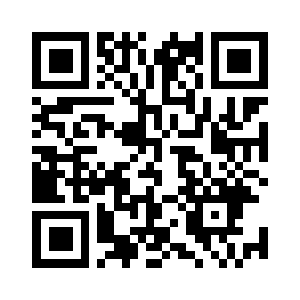


用自己的手機掃自己的 QR Code → 按 ⛶ 全螢幕 → 保持「自動更新」勾選，
之後 Notebook 裡每一次 push(path) 都會自動更新你的手機畫面


In [4]:
#@title 【第 4 步 / 執行一次】產生「你自己的」手機網頁 + QR Code（每人獨有）
import os, glob, gradio as gr, qrcode
from IPython.display import display

try: demo.close()          # 重跑這格時先關掉舊的 server
except Exception: pass

GR6 = int(gr.__version__.split(".")[0]) >= 6
VIDEO_EXT = (".mp4", ".gif"); IMAGE_EXT = (".png", ".jpg", ".jpeg")

BROADCAST = {"file": None}          # ← 最近一次 push 的檔案（顯示在你手機上）

def push(path):
    """把投影檔推播到「你自己的」手機頁面（約 2 秒內自動切換）。"""
    BROADCAST["file"] = os.path.basename(str(path))
    print(f"📡 已推播到你的手機頁面：{BROADCAST['file']}")
    return path

def holo_files():
    fs = sorted(glob.glob(os.path.join(OUT_DIR, "*")))
    return [os.path.basename(f) for f in fs
            if f.lower().endswith(IMAGE_EXT + VIDEO_EXT)] or ["（尚未產生任何投影檔）"]

def pick(name):
    p = os.path.join(OUT_DIR, name or "")
    if not os.path.isfile(p):
        return gr.update(value=None, visible=True), gr.update(value=None, visible=False)
    if p.lower().endswith(VIDEO_EXT):
        return gr.update(value=None, visible=False), gr.update(value=p, visible=True)
    return gr.update(value=p, visible=True), gr.update(value=None, visible=False)

def sync(cur, following):
    tgt = BROADCAST["file"]
    if not following or not tgt or tgt == cur:
        return gr.skip(), gr.skip(), gr.skip()
    im_u, vd_u = pick(tgt)
    return gr.update(value=tgt, choices=holo_files()), im_u, vd_u

BLACK_CSS = """
html, body, gradio-app, .gradio-container, .main, .wrap, .contain {
  background:#000 !important; color:#888 !important;
  margin:0 !important; padding:0 !important; max-width:100% !important; }
footer, .footer, .show-api, .built-with, .settings { display:none !important; }
#stage { display:flex; justify-content:center; align-items:center;
         background:#000 !important; border:none !important; }
#stage img, #stage video { width:100vmin !important; height:100vmin !important;
         object-fit:contain !important; background:#000 !important;
         border:none !important; border-radius:0 !important; }
.bar { opacity:.55; }
"""
FULLSCREEN_JS = """
() => { const el = document.documentElement;
        if (!document.fullscreenElement) { el.requestFullscreen?.(); }
        else { document.exitFullscreen?.(); } }
"""

img_kw = dict(type="filepath", show_label=False, container=False, interactive=False)
vid_kw = dict(show_label=False, autoplay=True, loop=True, container=False, interactive=False)
blocks_kw = dict(title="工數 II 全息投影")
launch_kw = dict(share=True, quiet=True, prevent_thread_lock=True, show_error=True)
if GR6:
    img_kw["buttons"] = []; vid_kw["buttons"] = []
    launch_kw.update(theme=gr.themes.Base(), css=BLACK_CSS)
else:
    img_kw["show_download_button"] = False; vid_kw["show_download_button"] = False
    blocks_kw.update(theme=gr.themes.Base(), css=BLACK_CSS)

with gr.Blocks(**blocks_kw) as demo:
    with gr.Row(elem_classes="bar"):
        dd = gr.Dropdown(holo_files(), value=holo_files()[0], show_label=False,
                         scale=4, container=False)
        fo = gr.Checkbox(value=True, label="自動更新", scale=1, container=False)
        rb = gr.Button("↻ 重新整理", scale=1, size="sm")
        fb = gr.Button("⛶ 全螢幕", scale=1, size="sm")
    with gr.Column(elem_id="stage"):
        im = gr.Image(**img_kw)
        vd = gr.Video(**vid_kw)

    tick = gr.Timer(1.5)                       # 每 1.5 秒檢查一次有沒有新的 push
    dd.change(pick, dd, [im, vd])
    rb.click(lambda: gr.update(choices=holo_files()), None, dd)
    fb.click(None, None, None, js=FULLSCREEN_JS)
    tick.tick(sync, [dd, fo], [dd, im, vd])
    demo.load(pick, dd, [im, vd])

demo.launch(**launch_kw)
URL = demo.share_url or demo.local_url
print("Gradio", gr.__version__, "｜ 你的個人網址（只屬於這份 Colab）：", URL)
display(qrcode.make(URL).resize((300, 300)))
print("\n用自己的手機掃自己的 QR Code → 按 ⛶ 全螢幕 → 保持「自動更新」勾選，\n"
      "之後 Notebook 裡每一次 push(path) 都會自動更新你的手機畫面")

[ok] holo_out/S0_calibration.png  (1080x1080 靜態圖)


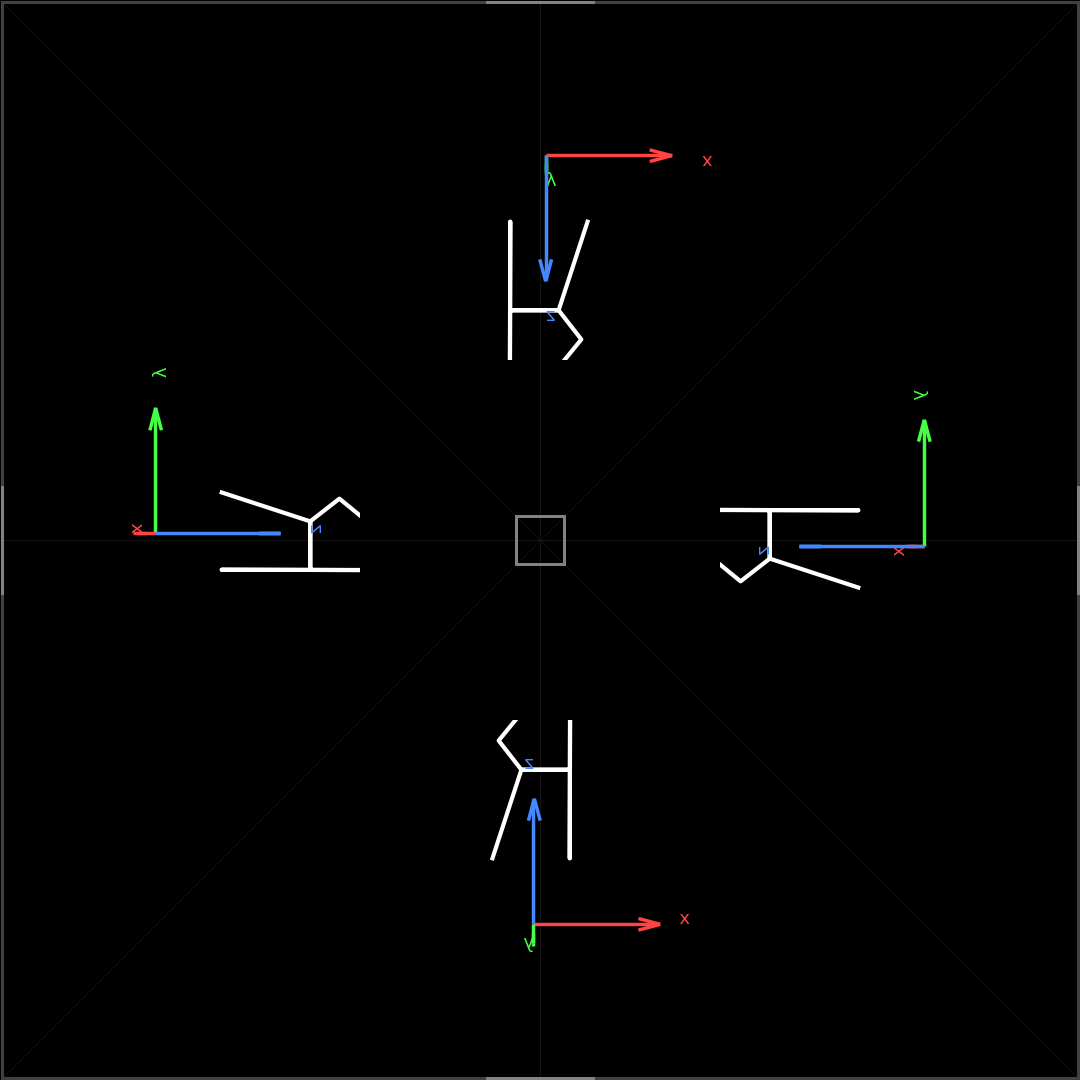

檔案：holo_out/S0_calibration.png   ← 左側『檔案』面板可下載，或用下方 Web 介面推到手機
📡 已推播到你的手機頁面：S0_calibration.png

怎麼調（每改一次數值就重新執行本格，手機約 2 秒後自動更新）：
  方框比金字塔底座「大」   → offset 或 view_px 調小
  方框比金字塔底座「小」   → offset 或 view_px 調大
  影像被金字塔邊緣切到     → zoom 調小
  影像太小看不清楚         → zoom 調大
  想讓影像整體浮高一點     → offset 調小（view_px 也一起調小，避免四格互相重疊）
  格線太亮／太暗           → grid_level（正式上課想關掉格線就設 0）

對齊完成後，把 grid_level 改回 55（或 0）再執行一次本格，投影會乾淨很多。

調好之後，之後所有投影圖／影片都會自動用這組參數。
（少數格子為了特定場景另外指定了 zoom=...，那些會蓋過這裡的 zoom。）



In [16]:
#@title 【第 5 步】依據你的手機螢幕調整參數（改右側數值 → 執行 → 手機自動更新）
#@markdown 手機掃好 QR、按 ⛶ 全螢幕、金字塔放到畫面正中央之後，
#@markdown 來回調整下面的數值，直到**外圍方框剛好對齊金字塔底座四條邊**為止。
#@markdown 每支手機螢幕大小不同，所以這組數值是**你個人的**，調好整學期不用再動。

offset     = 390    #@param {type:"integer"}
view_px    = 420    #@param {type:"integer"}
zoom       = 2.2   #@param {type:"number"}
grid_level = 20    #@param {type:"integer"}

CFG.update(offset=int(offset), view_px=int(view_px),
           zoom=float(zoom), grid_level=int(grid_level))

path = render_hologram(draw_calibration, "S0_calibration.png", lim=1.2, elev=8)
show_png(path, width=380)
push(path)                     # 推到你自己的手機頁面

print("""
怎麼調（每改一次數值就重新執行本格，手機約 2 秒後自動更新）：
  方框比金字塔底座「大」   → offset 或 view_px 調小
  方框比金字塔底座「小」   → offset 或 view_px 調大
  影像被金字塔邊緣切到     → zoom 調小
  影像太小看不清楚         → zoom 調大
  想讓影像整體浮高一點     → offset 調小（view_px 也一起調小，避免四格互相重疊）
  格線太亮／太暗           → grid_level（正式上課想關掉格線就設 0）

對齊完成後，把 grid_level 改回 55（或 0）再執行一次本格，投影會乾淨很多。

調好之後，之後所有投影圖／影片都會自動用這組參數。
（少數格子為了特定場景另外指定了 zoom=...，那些會蓋過這裡的 zoom。）
""")

---
# Session 0 ｜ 熱身：輸入一個向量，把它變成全息投影

這一段的目的只有一個：**讓每個人在 5 分鐘內完成「打字 → 看到 3D → 手機上看到懸浮影像」的完整流程。**
之後所有 Phase 都是重複同樣的三個動作。

### 你只需要認得三個指令

```python
Scene()                       # 開一張空白的 3D 畫布
   .arrow([2, 1, 0], RED, "a1")   # 畫一根從原點出發的向量（箭頭）
   .point([2, 4, 4], GREEN, "b")  # 畫一個點（懸浮小球）
```

向量就是 `[x, y, z]` 三個數字。**改數字 = 改向量**，沒有別的。

S0-2 產生的投影圖會自動 `push` 到你手機的網頁上（第 4 步做好的那個）。

In [17]:
#@title S0-1　輸入你的向量 → 在 Colab 裡用滑鼠拖曳旋轉（3D 預覽）
import numpy as np

# ============== 改這裡：把數字換成你想畫的向量 ==============
my_vector   = [2, 1, 0]      # 你的第一個向量
my_vector_2 = [0, 1, 2]      # 你的第二個向量（不想畫就設成 None）
my_point    = [2, 4, 4]      # 一個懸浮的目標點（不想畫就設成 None）
# ==========================================================

sc = Scene()
sc.arrow(my_vector, RED, "v1")
if my_vector_2 is not None:
    sc.arrow(my_vector_2, "#4D9BFF", "v2")
if my_point is not None:
    sc.point(my_point, GREEN, "b")

sc.show("S0 我的第一個向量 —— 用滑鼠拖曳可以旋轉視角")
print("向量長度 |v1| =", round(float(np.linalg.norm(my_vector)), 3))

向量長度 |v1| = 2.236


[ok] holo_out/S0_my_vector.png  (1080x1080 靜態圖)
📡 已推播到你的手機頁面：S0_my_vector.png


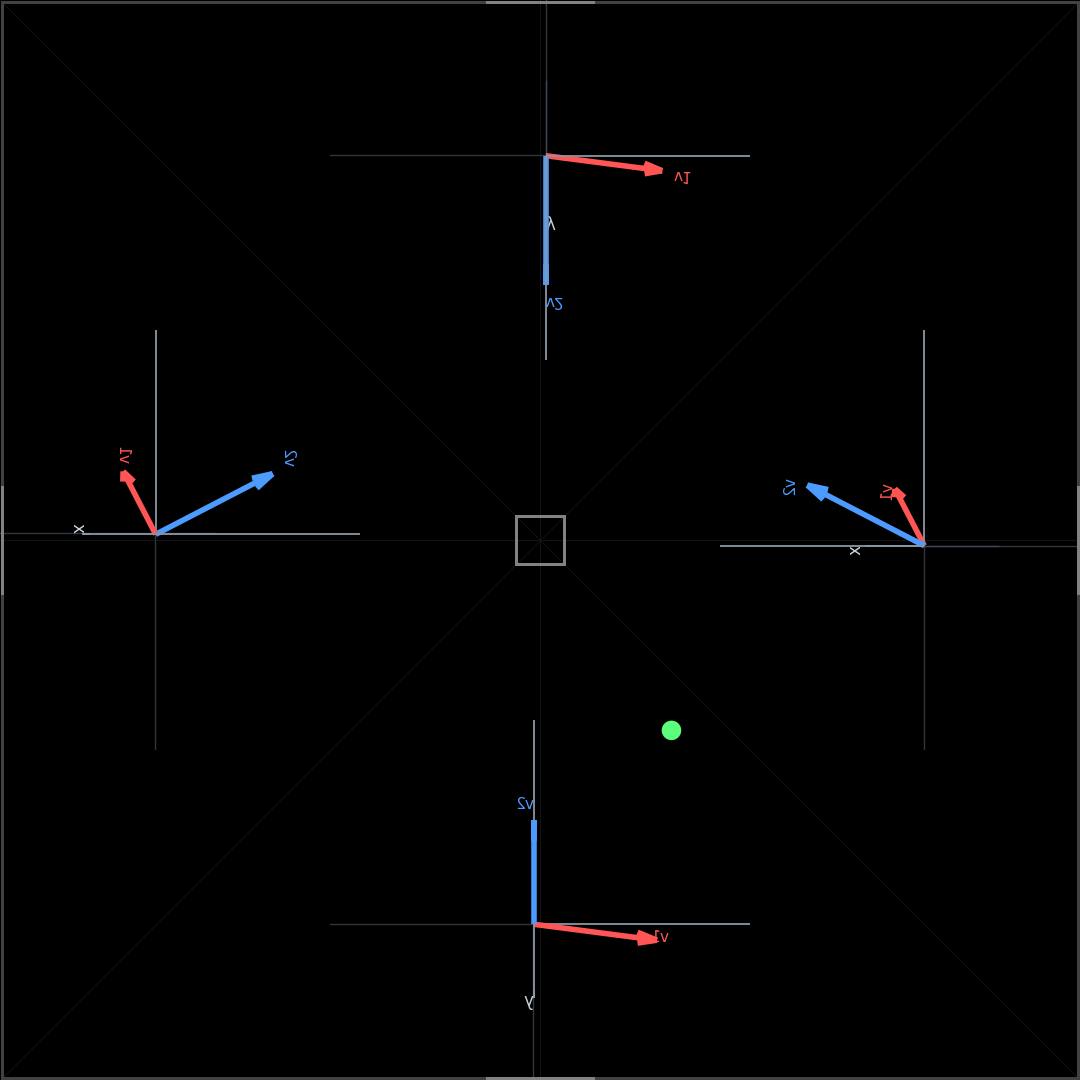

檔案：holo_out/S0_my_vector.png   ← 左側『檔案』面板可下載，或用下方 Web 介面推到手機


In [18]:
#@title S0-2　把剛才那張 3D 圖變成金字塔投影圖（含對齊格線）
#
# 同一個 sc（場景）直接輸出成四視角全息版面。
# 圖上的格線是給你對齊金字塔用的：
#     ┌─ 中央十字 + 中心小方框  →  金字塔「頂點」對準這裡
#     ├─ 外圍大方框            →  金字塔「底座四條邊」壓在這條線上
#     ├─ 四條對角線            →  金字塔四條稜線的位置
#     └─ 四邊中點的粗白短線    →  快速確認有沒有歪掉
#
path = sc.to_hologram("S0_my_vector.png")
try:
    push(path)          # 推到你自己的手機頁面
except NameError:
    print("（提示：先執行第 4 步產生你的網頁，這張圖就能直接推到手機上）")
show_png(path)

---
# Phase 1 ｜ Engage 引起動機（00:00 – 00:30）

> **情境**：一台無人機裝了 2 顆推進器，噴射產生的位移向量分別是
> $\mathbf{a}_1=(2,1,0)^T$ 與 $\mathbf{a}_2=(0,1,2)^T$。
> 調油門 = 純量縮放；兩顆同時開 = 向量相加（首尾相接）。
>
> **關鍵提問**：空間中有一個目標點 $\mathbf{b}=(2,4,4)^T$（綠色懸浮球）。
> 只靠這兩個向量伸縮相加，無人機**能不能**精準抵達這個點？

**口語表述活動 1（鷹架句型）**
「我認為【可以／不可以】到達，因為這兩個向量在空間中只能構成【一個平面】，而目標點 b 看起來【有／沒有】落在上面。」

In [22]:
#@title P1-1　兩顆推進器 + 合成向量 + 目標點 b（先在 Colab 看 3D）
a1 = np.array([2., 1., 0.])     # 推進器 1 的位移向量
a2 = np.array([0., 1., 2.])     # 推進器 2 的位移向量
b  = np.array([2., 4., 4.])     # 懸浮目標點

x1 = 1.5
x2 = 1.2              # ← 油門大小，改這兩個數字看合成向量怎麼動
v = x1 * a1 + x2 * a2

sc = (Scene(lim=5)
      .arrow(x1 * a1, RED,      "x1·a1")
      .arrow(x2 * a2, "#4D9BFF", "x2·a2", origin=x1 * a1)   # 首尾相接
      .arrow(v,       YELLOW,   "v = x1a1 + x2a2")
      .point(b, GREEN, "b (target)"))
sc.show("P1 無人機能不能飛到綠球？（拖曳旋轉看看 b 到底在不在那張斜面上）")

print(f"目前合成向量 v = {v}")
print(f"目標點     b = {b}")
print("差距 |v - b| =", round(float(np.linalg.norm(v - b)), 3))

目前合成向量 v = [3.  2.7 2.4]
目標點     b = [2. 4. 4.]
差距 |v - b| = 2.291


In [24]:
#@title P1-2　產生 Engage 用的全息動畫（合成向量掃過整張平面 + 懸空的 b）
#
# 動畫內容：x1、x2 兩個係數連續變化，黃色合成向量的頂端掃出一整張平面，
#           綠色目標點 b 始終懸在平面外 —— 學生用肉眼就能看出「碰不到」。
#
def engage_scene(t):
    ang = 2 * np.pi * t
    x1 = 1.6 * np.cos(ang)
    x2 = 1.6 * np.sin(ang)
    v = x1 * a1 + x2 * a2
    s = Scene(lim=5)
    #s.span_plane(a1, a2, color="#0E6B78", rng=1.15, n=7, alpha=0.9)  # 可達範圍（暗青）
    s.arrow(x1 * a1, RED)
    s.arrow(x2 * a2, "#4D9BFF", origin=x1 * a1)
    s.arrow(v, YELLOW)
    s.point(b, GREEN, "b", size=13)
    return s

path = animate_hologram(engage_scene, "P1_engage_drone.mp4",
                        n_frames=60, loop_back=False)
push(path)
play(path)

[ok] holo_out/P1_engage_drone.mp4  (60 影格 @ 20fps)
📡 已推播到你的手機頁面：P1_engage_drone.mp4


檔案：holo_out/P1_engage_drone.mp4


---
# Phase 2 ｜ Explore 探索操作（00:30 – 01:15）

## Task 1（00:30 – 00:50）線性組合與點雲平面

拖動滑桿 $x_1, x_2 \in [-3, 3]$，觀察合成向量頂點的軌跡，再一鍵生成 500 個隨機組合點。

**口語表述活動 2（鷹架句型）**
「當我調整所有係數 $(x_1,x_2)$ 時，合成向量的所有頂點在空間中鋪成了一張【通過原點的 2D 平面】，
這代表這兩個向量的張成空間維度是【2】維。」

In [25]:
#@title P2-1　滑桿：拖動 x1、x2，看合成向量的頂點跑到哪裡
%matplotlib inline
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

@interact(x1  =FloatSlider(value=1.0, min=-3, max=3, step=0.1,
                           description="x1 油門", continuous_update=False),
          x2  =FloatSlider(value=1.0, min=-3, max=3, step=0.1,
                           description="x2 油門", continuous_update=False),
          視角=FloatSlider(value=45, min=0, max=360, step=5,
                           description="視角", continuous_update=False))
def _explore(x1=1.0, x2=1.0, 視角=45):
    v = x1 * a1 + x2 * a2
    sc = (Scene(lim=6)
          .span_plane(a1, a2, color="#0E6B78", rng=1.3, n=9, alpha=0.9)
          .arrow(x1 * a1, RED)
          .arrow(x2 * a2, "#4D9BFF", origin=x1 * a1)
          .arrow(v, YELLOW, "v")
          .point(b, GREEN, "b"))

    fig = plt.figure(figsize=(6, 6), facecolor="black")
    ax = fig.add_subplot(111, projection="3d", facecolor="black")
    sc.draw(ax)
    L = sc.lim
    ax.set_xlim(-L, L); ax.set_ylim(-L, L); ax.set_zlim(-L, L)
    ax.set_box_aspect((1, 1, 1), zoom=1.3)
    ax.view_init(elev=18, azim=視角)
    ax.set_axis_off()
    ax.set_title(f"v = {x1:.1f}a1 + {x2:.1f}a2 = "
                 f"({v[0]:.1f}, {v[1]:.1f}, {v[2]:.1f})", color="white")
    plt.show()
    print(f"目標點 b = {b}　　差距 |v - b| = {np.linalg.norm(v - b):.3f}")

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='x1 油門', max=3.0, min=-3.0),…

[ok] holo_out/P2_task1_cloud.png  (1080x1080 靜態圖)


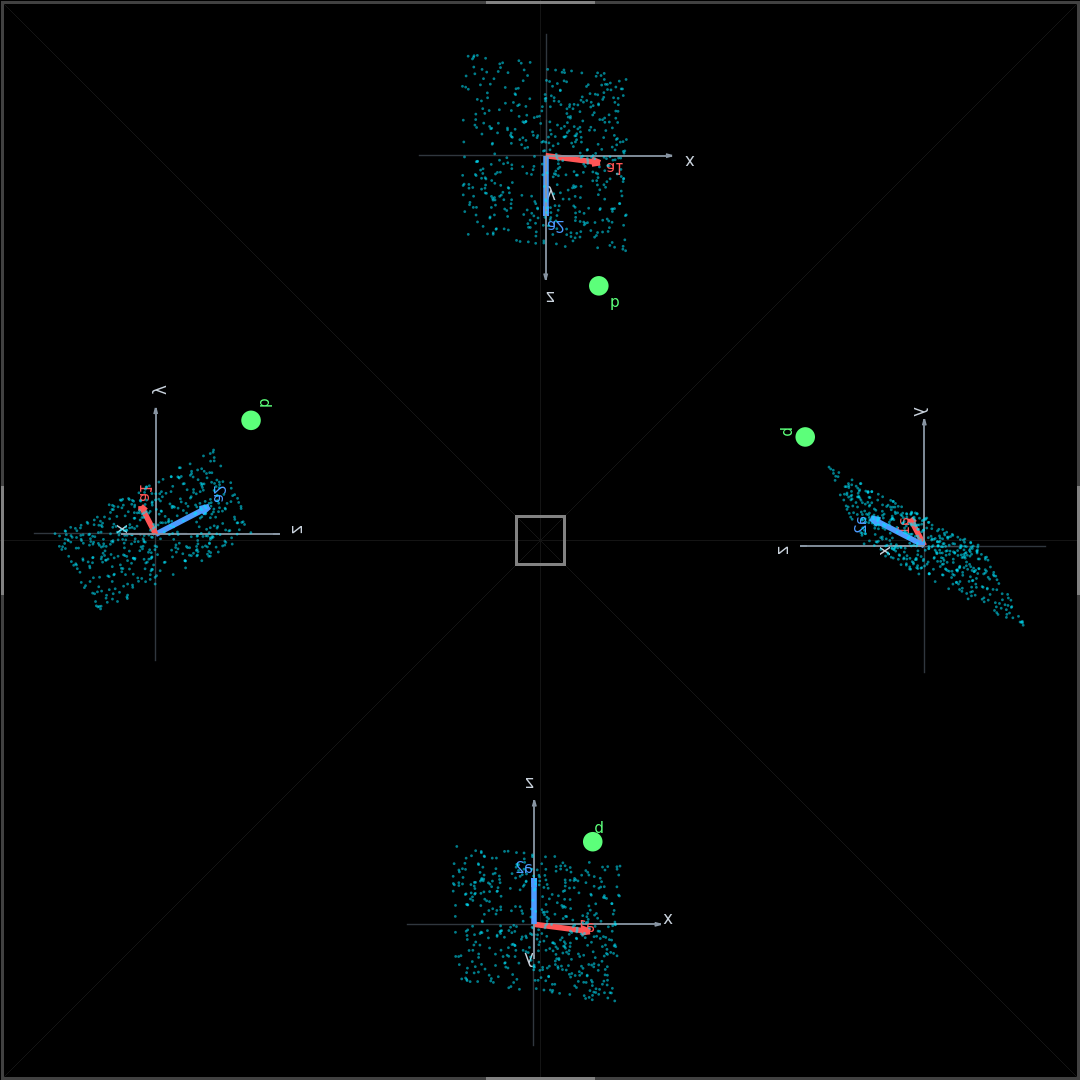

檔案：holo_out/P2_task1_cloud.png   ← 左側『檔案』面板可下載，或用下方 Web 介面推到手機


In [27]:
#@title P2-2　一鍵生成 500 個隨機線性組合點 → 3D 預覽 → 全息投影
#可自行調整 rng.uniform(X, X, size=(N,2)) 的參數, 改變點雲的範圍

N = 500                                   # 點的數量
rng = np.random.default_rng(0)
coef = rng.uniform(-1.5, 1.5, size=(N, 2))          # 隨機的 (x1, x2)
cloud_pts = coef @ np.vstack([a1, a2])              # 每一列 = x1·a1 + x2·a2

sc_cloud = (Scene(lim=5)
            .cloud(cloud_pts, CYAN, size=2, opacity=0.55)
            .arrow(a1, RED, "a1")
            .arrow(a2, "#4D9BFF", "a2")
            .point(b, GREEN, "b"))
sc_cloud.show("P2 Task1：500 個線性組合點鋪成什麼形狀？有沒有通過原點？")

# 產生全息版（點雲較滿，zoom 調小一點避免溢出格子）
path = sc_cloud.to_hologram("P2_task1_cloud.png", zoom=1.10)
show_png(path)

In [ ]:
push(path)

📡 已推送到學生手機：P2_task1_cloud.png


'holo_out/P2_task1_cloud.png'

# Task 2: 第 3 向量 (第 3 個推進器) ➔ 先幾何觀察，後行消去法驗證

- **Case 1**：$\mathbf{a}_3 = 2\mathbf{a}_1 + \mathbf{a}_2 = (4,3,2)^T$
- **Case 2**：$\mathbf{a}_3 = (0,0,3)^T$

先用肉眼旋轉觀察 $\mathbf{a}_3$ 是否共面，**再**執行行消去法驗證第三行會不會被消成 $\mathbf{0}$。

In [36]:
#@title -------- Case 1：a3 為 a1, a2 的線性組合 (自己改) ---------
w1 = 2 #<--- 自己改
w2 = 1 #<--- 自己改
a3_case1 = w1 * a1 + w2 * a2
print(f"Case 1：a3 = {w1}*a1 + {w2}*a2 =", a3_case1)


Case 1：a3 = 2*a1 + 1*a2 = [4. 3. 2.]


[ok] holo_out/P2_task1_cloud_a3.png  (1080x1080 靜態圖)


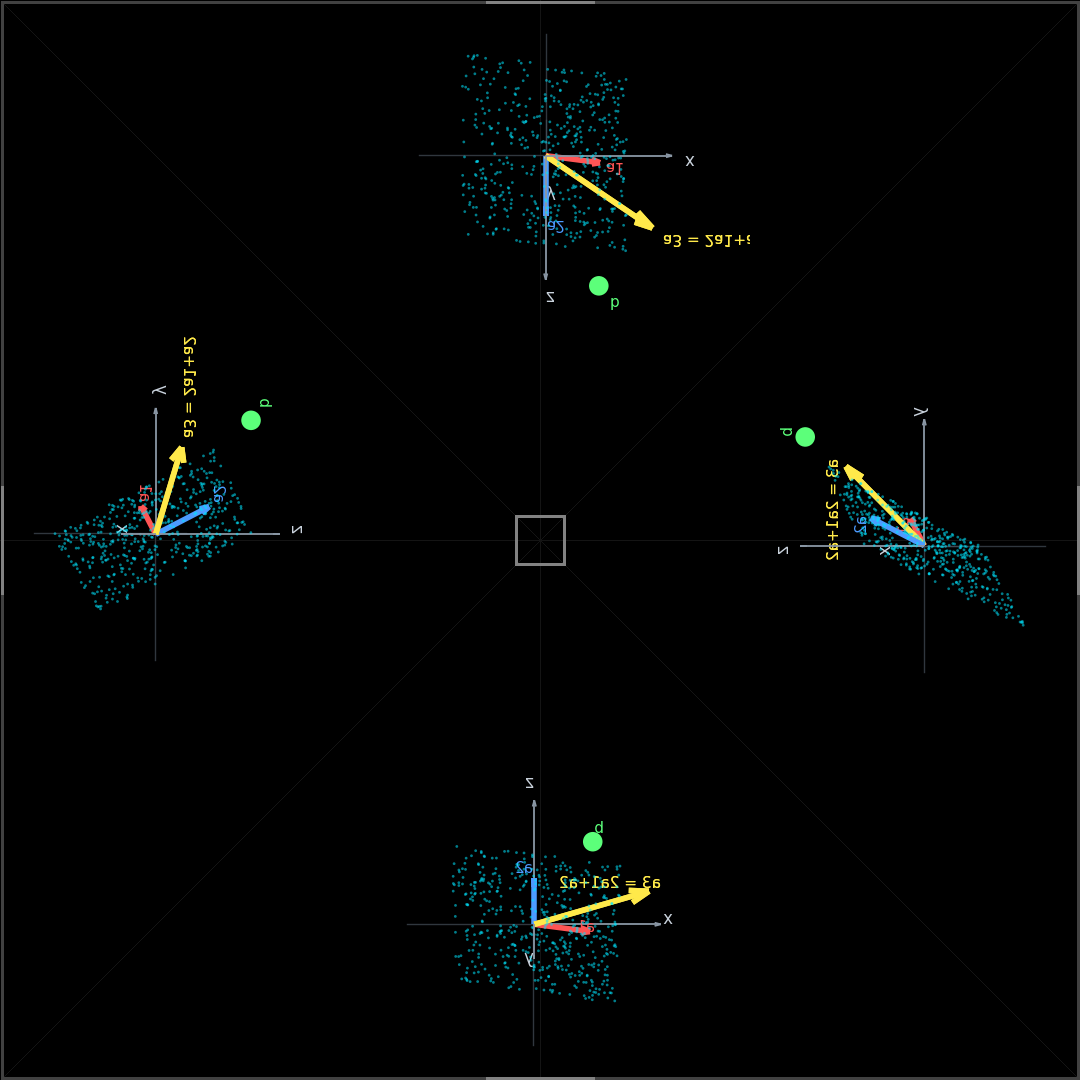

檔案：holo_out/P2_task1_cloud_a3.png   ← 左側『檔案』面板可下載，或用下方 Web 介面推到手機
📡 已推播到你的手機頁面：P2_task1_cloud_a3.png


'holo_out/P2_task1_cloud_a3.png'

In [35]:
# 把 a3_case1 加到點雲圖, 觀察他在點雲裡面還是外面
sc_cloud.arrow(a3_case1, YELLOW, "a3 = 2a1+a2")     # 疊加到既有場景上

sc_cloud.show("加入 a3 之後：它落在點雲裡面還是外面？")   # Colab 重新預覽

path = sc_cloud.to_hologram("P2_task1_cloud_a3_case1.png", zoom=1.10)
show_png(path)
push(path)

In [38]:
#@title -------- Case 2：a3 隨便猜一個 ---------

a3_case2 = [-1, 1, 1]
print(f"Case 2：a3 = ", a3_case2)


Case 2：a3 =  [-1, 1, 1]


[ok] holo_out/P2_task1_cloud_a3_case2.png  (1080x1080 靜態圖)


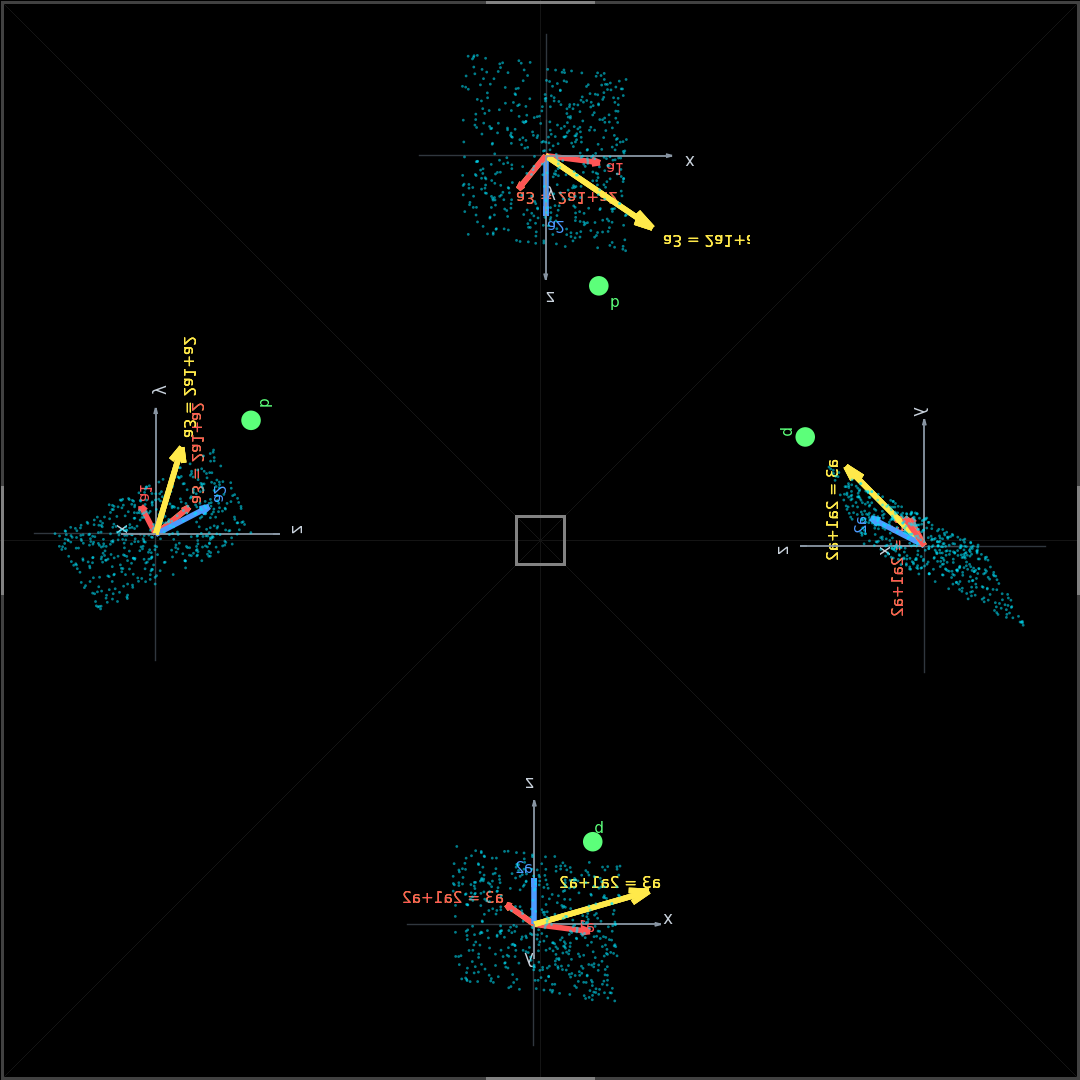

檔案：holo_out/P2_task1_cloud_a3_case2.png   ← 左側『檔案』面板可下載，或用下方 Web 介面推到手機
📡 已推播到你的手機頁面：P2_task1_cloud_a3_case2.png


'holo_out/P2_task1_cloud_a3_case2.png'

In [43]:
# 把 a3_case2 加到上面的點雲圖裡, 觀察是否"埋在"雲裡
# 如果你隨便猜的 a3_case2 埋在點雲裡, 再重猜一次
sc_cloud.arrow(a3_case2, RED, "a3 = 2a1+a2")     # 疊加到既有場景上

sc_cloud.show("加入 a3 之後：它落在點雲裡面還是外面？")   # Colab 重新預覽

path = sc_cloud.to_hologram("P2_task1_cloud_a3_case2.png", zoom=1.10)
show_png(path)
push(path)

##P2-3　行消去法（Column Reduction）：把行向量減掉前面行向量的倍數
## 代數操作: 給定一個新的向量 a3, 如何很快地知道它是否在原本的點雲內, 或突破了點雲??

In [65]:
#@title -------- Case 1：a3 為 a1, a2 的線性組合 ---------
# case1: a3 = [4,3,2]

a1 = np.array([2., 1., 0.])     # 推進器 1 的位移向量
a2 = np.array([0., 1., 2.])     # 推進器 2 的位移向量
a3_case1 = np.array([4., 3., 2.])

# 行消去: 把行向量減掉前面行向量的倍數
a3_r1 = a3_case1 - 2*a1
print(a3_r1)

[0. 1. 2.]


In [66]:
a3_r2 = a3_r1 - a2
print(a3_r2)

[0. 0. 0.]


In [ ]:
# 開一個新畫布, 把剛剛的 a1, a2, a3_case1, a3_case2, a3_r1, a3_r2 一個一個加上去

In [67]:
sc = (Scene(lim=5)
      .arrow(a1, RED,    "a1")
      .arrow(a2, "#4D9BFF", "a2")
      .arrow(a3_case1, YELLOW,   "a3")
      .arrow(a3_r1, ORANGE, f"a3_r1 ={a3_r1} 是 a3 和 a1 的組合"))
sc.show("a1, a2 和 a3_case1 -- 重畫一下")   # Colab 重新預覽

In [69]:
# 把 a3_r2 加進去
sc.arrow(a3_r2, ORANGE, f"a3_r2={a3_r2}")     # 疊加到既有場景上
sc.show("a1, a2 和 a3_case1 -- r2")   # Colab 重新預覽

In [52]:
#@title -------- Case 2：a3 是你剛剛亂猜的那個 ---------

# case2: a3 = [-1, 1, 1]

a1 = np.array([2., 1., 0.])     # 推進器 1 的位移向量
a2 = np.array([0., 1., 2.])     # 推進器 2 的位移向量
a3_case2 = np.array([-1, 1, 1])

# 行消去: 把行向量減掉前面行向量的倍數
a3_r1 = 2*a3_case2 + a1
print(a3_r1)

[0. 3. 2.]


In [53]:
a3_r2 = a3_r1 - 3*a2
print(a3_r2)

[ 0.  0. -4.]


In [ ]:
# 開一個新畫布, 把剛剛的 a1, a2, a3_case1, a3_case2, a3_r1, a3_r2 一個一個加上去

In [61]:
sc = (Scene(lim=5)
      .arrow(a1, RED,    "a1")
      .arrow(a2, "#4D9BFF", "a2")
      .arrow(a3_case2, YELLOW,   "a3")
      .arrow(a3_r1, ORANGE, f"a3_r1 ={a3_r1} 是 a3 和 a1 的組合"))
sc.show("a1, a2 和 a3_case2 -- 行消去 r1")   # Colab 重新預覽

In [63]:
sc.arrow(a3_r2, ORANGE, "a3_r2")     # 疊加到既有場景上
sc.show("a1, a2 和 a3_case2: 行消去r2")   # Colab 重新預覽

### 小整理:
Case 1：a3 = 2a1 + a2 = [4. 3. 2.] （落在點雲內）  
   A =   
 [[2. 0. 4.]  
 [1. 1. 3.]  
 [0. 2. 2.]]  
   a1 仍為非零、帶來新方向  ✔ 獨立  
   a2 仍為非零、帶來新方向  ✔ 獨立  
   a3 ← a3 − (2)·a1   ⇒ [0. 1. 2.]  
   a3 ← a3 − (1)·a2   ⇒ [0. 0. 0.]  
   a3 被消成 0 向量  ✘ 線性相依（沒有增加空間維度）  
  
   → 消去後矩陣：  
[[2. 0. 0.]  
 [1. 1. 0.]  
 [0. 2. 0.]]  
   → Rank = 獨立行向量的個數 = 2  
  
============================================================

Case 2：a3 = [0. 0. 3.] （落在點雲外，往 z 軸戳出去）
   A =   
 [[2. 0. 0.]  
 [1. 1. 0.]  
 [0. 2. 3.]]  
   a1 仍為非零、帶來新方向  ✔ 獨立  
   a2 仍為非零、帶來新方向  ✔ 獨立  
   a3 仍為非零、帶來新方向  ✔ 獨立  

   → 消去後矩陣：  
[[2. 0. 0.]  
 [1. 1. 0.]  
 [0. 2. 3.]]  
   → Rank = 獨立行向量的個數 = 3

In [ ]:
#@title P2-4　Case 1 vs Case 2：點雲是「薄片」還是「膨脹成立體」？（3D 預覽）
M = 900
c2 = rng.uniform(-1.2, 1.2, size=(M, 3))

pts_case1 = c2 @ np.vstack([a1, a2, a3_case1])     # 依然被困在 2D 平面
pts_case2 = c2 @ np.vstack([a1, a2, a3_case2])     # 膨脹成 3D 實心立體

sc_c1 = (Scene(lim=6).cloud(pts_case1, CYAN, size=2, opacity=0.45)
         .arrow(a1, RED, "a1").arrow(a2, "#4D9BFF", "a2")
         .arrow(a3_case1, YELLOW, "a3 = 2a1+a2"))
sc_c1.show("Case 1：a3 = 2a1 + a2 → 點雲仍是一張 2D 薄片（Rank = 2）")

sc_c2 = (Scene(lim=6).cloud(pts_case2, MAGENTA, size=2, opacity=0.30)
         .arrow(a1, RED, "a1").arrow(a2, "#4D9BFF", "a2")
         .arrow(a3_case2, GREEN, "a3 (new dir)"))
sc_c2.show("Case 2：a3 = (0,0,3) → 點雲膨脹填滿 3D 空間（Rank = 3）")

[ok] holo_out/P2_case1_rank2_flat.png  (1080x1080 靜態圖)
[ok] holo_out/P2_case2_rank3_solid.png  (1080x1080 靜態圖)


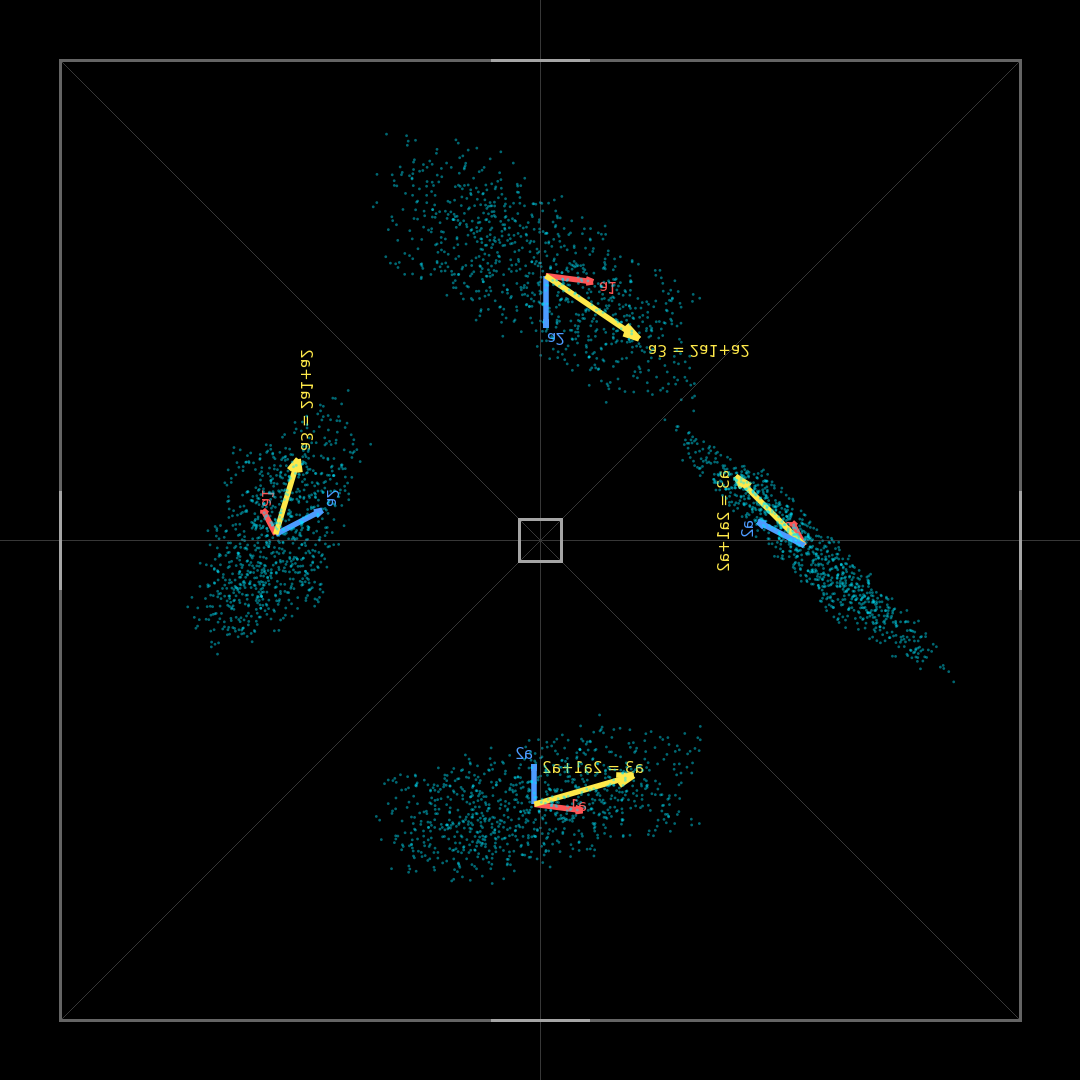

檔案：holo_out/P2_case1_rank2_flat.png   ← 左側『檔案』面板可下載，或用下方 Web 介面推到手機


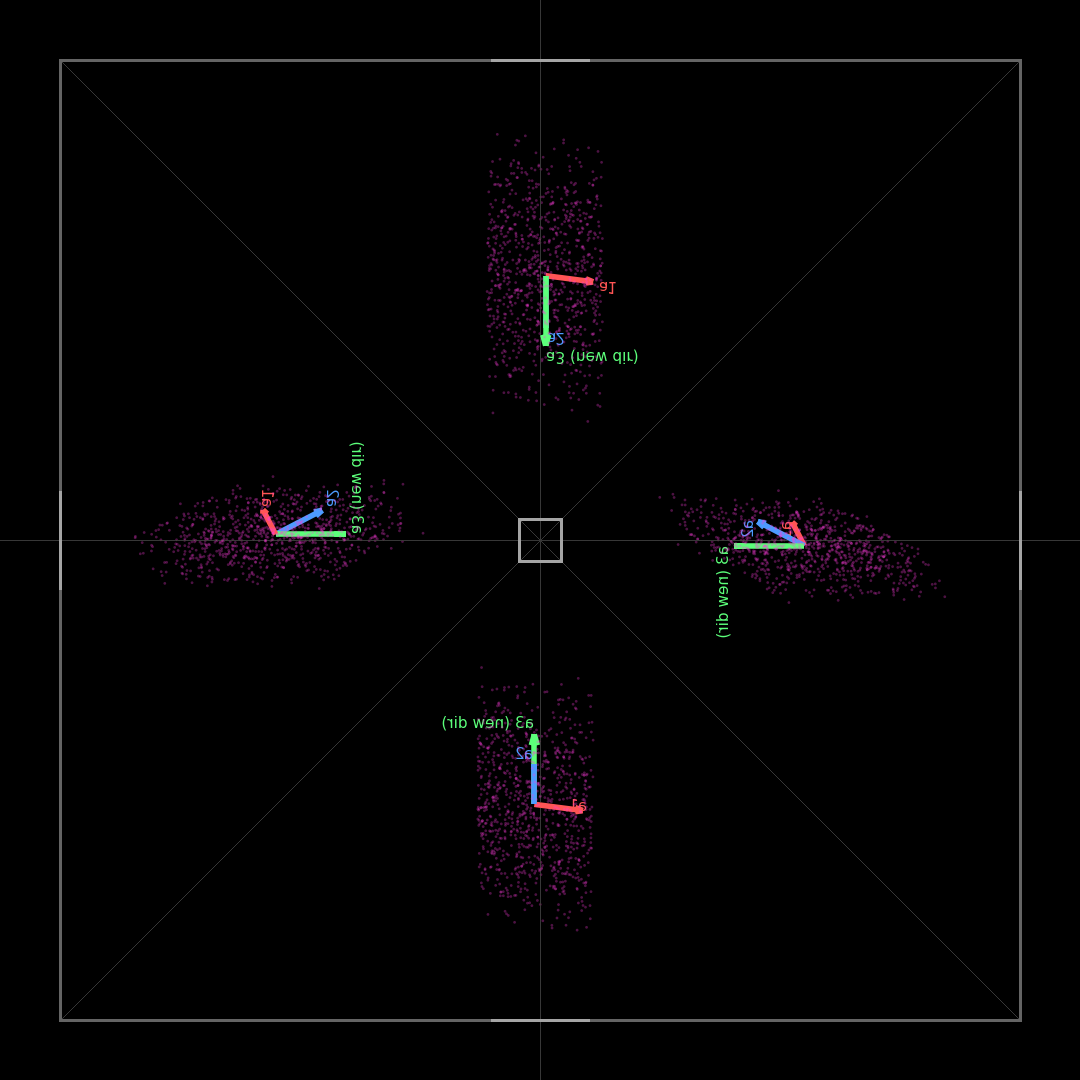

檔案：holo_out/P2_case2_rank3_solid.png   ← 左側『檔案』面板可下載，或用下方 Web 介面推到手機

課堂提問：為什麼 Case 1 加入了第 3 個向量，行消去後第三行會被消成 0，
          且點雲依然被困在 2D 平面？


In [ ]:
#@title P2-5　產生 Case 1 / Case 2 的全息投影圖（課堂上兩支手機並排對比最有效）
p1 = sc_c1.to_hologram("P2_case1_rank2_flat.png", zoom=1.15)
p2 = sc_c2.to_hologram("P2_case2_rank3_solid.png", zoom=1.15)
show_png(p1); show_png(p2)
print("\n課堂提問：為什麼 Case 1 加入了第 3 個向量，行消去後第三行會被消成 0，")
print("          且點雲依然被困在 2D 平面？")

In [ ]:
push(p2)

📡 已推送到學生手機：P2_case2_rank3_solid.png


'holo_out/P2_case2_rank3_solid.png'

## P2-6 Ax = b 是否有解: column view
(要回到投影片講解)

---
# Phase 3 ｜ Explain 解釋概念（01:15 – 01:55）

## 幾何 ↔ 代數

| 幾何現象（學生剛剛看到的） | 數學語言（正式定義） |
|---|---|
| 向量鋪出的那張平面 | $\text{Col}(A)=\text{span}\{\mathbf{a}_1,\mathbf{a}_2,\mathbf{a}_3\}$ |
| 向量方向重疊／共面 | 線性相依（$\det = 0$） |
| 行消去後剩下的非零向量個數 | $\text{Rank}(A)$ |
| 目標點懸在平面外 | 無解（Inconsistent） |

$$A\mathbf{x}=\mathbf{b} \text{ 有解} \iff \mathbf{b}\in\text{Col}(A)$$

**口語表述活動 3（隨機抽問）**
「請用一句**完全不帶代數符號**的話，向隔壁同學解釋什麼是 Rank？為什麼行消去法可以算 Rank？」

---

## 雙重視角對比（01:35 – 01:55）

- **Column View（本週）**：行向量線性組合，行消去法在「化簡向量基底」。
- **Row View（下週）**：聯立方程式中的平面交集，列消去法在「旋轉替換平面」。
- 兩者從不同幾何角度出發，但算出的 $\text{Rank}$ 必然相等。

In [ ]:
#@title P3-1　Column View vs Row View：同一個方程組的兩種幾何（3D 預覽）
A_demo = np.column_stack([a1, a2, a3_case2])     # 行向量視角：三根獨立向量
b_demo = np.array([2., 4., 4.])
x_sol = np.linalg.solve(A_demo, b_demo)
print("A =\n", A_demo, "\nb =", b_demo)
print("解 x =", np.round(x_sol, 3), "  （= 三根向量各要伸縮多少倍）")

# ---- 左圖：Column View（向量首尾相接抵達 b）----
steps, cur = [np.zeros(3)], np.zeros(3)
for k in range(3):
    cur = cur + x_sol[k] * A_demo[:, k]
    steps.append(cur.copy())

sc_col = Scene(lim=6)
for k, col in enumerate([RED, "#4D9BFF", GREEN]):
    sc_col.arrow(x_sol[k] * A_demo[:, k], col, f"x{k+1}·a{k+1}", origin=steps[k])
sc_col.polyline(np.array(steps), GREY, width=1, dashed=True)
sc_col.point(b_demo, YELLOW, "b")
sc_col.show("Column View：三根行向量伸縮後首尾相接，剛好走到 b")

# ---- 右圖：Row View（三個平面交於一點）----
sc_row = Scene(lim=6)
for r, rhs, col in zip(A_demo, b_demo, [CYAN, MAGENTA, YELLOW]):
    sc_row.plane_eq(r, rhs, color=col, rng=1.1, n=6, alpha=0.55)
sc_row.point(x_sol, WHITE, "x*")
sc_row.show("Row View：每一列是一個平面方程式，三個平面交於同一點 = 唯一解")

A =
 [[2. 0. 0.]
 [1. 1. 0.]
 [0. 2. 3.]] 
b = [2. 4. 4.]
解 x = [ 1.     3.    -0.667]   （= 三根向量各要伸縮多少倍）


In [ ]:
#@title P3-2　產生雙重視角的全息投影圖
show_png(sc_col.to_hologram("P3_column_view.png", zoom=1.30))
show_png(sc_row.to_hologram("P3_row_view.png", zoom=1.20))
print("\n下週預告提問：如果方程式無解，Column View 看到的是目標點掉在平面外；")
print("              那 Row View 會看到平面的什麼幾何關係？")

---
# Phase 4 ｜ Elaborate 精緻化延伸（01:55 – 02:35）

## 任務：印刷機的色域盲區破案

某專業印刷機配備 3 罐墨水，光譜吸收向量為

$$\mathbf{c}_1=\begin{bmatrix}1\\0\\1\end{bmatrix},\quad
\mathbf{c}_2=\begin{bmatrix}0\\1\\1\end{bmatrix},\quad
\mathbf{c}_3=\begin{bmatrix}1\\1\\2\end{bmatrix}$$

客戶指定要印製兩種商標顏色：$\mathbf{b}_1=[2,3,5]^T$ 與 $\mathbf{b}_2=[1,1,0]^T$。
**請問哪一種顏色這台印刷機絕對調不出來？**

**小組發表鷹架句型**
「我們透過行消去法發現 $\mathbf{c}_3=\underline{\quad}$，被消成全零向量，因此這 3 個向量張成的行空間只有【　】維平面。
全息圖顯示【　】落在行空間平面上所以有解，而【　】懸在平面外，代表方程組【無解】。」

In [ ]:
#@title P4-1　【學生操作】輸入墨水矩陣，做行消去法，再看全息圖判斷
c1 = np.array([1., 0., 1.])
c2 = np.array([0., 1., 1.])
c3 = np.array([1., 1., 2.])
b1 = np.array([2., 3., 5.])
b2 = np.array([1., 1., 0.])

C = np.column_stack([c1, c2, c3])
print("墨水矩陣 C =\n", C, "\n")
print("行消去法過程：")
_, rank_C = column_reduce(C, names=["c1", "c2", "c3"])

print("\n" + "-" * 52)
for name, bb in [("b1 = [2,3,5]", b1), ("b2 = [1,1,0]", b2)]:
    ok, r1, r2 = has_solution(C, bb)
    print(f"{name}:  rank(C)={r1}, rank([C|b])={r2}  →  {'調得出來（有解）' if ok else '★ 調不出來（無解）'}")

sc_ink = (Scene(lim=6)
          .span_plane(c1, c2, color="#0E6B78", rng=1.25, n=9, alpha=0.9)   # 色域平面 Col(C)
          .arrow(c1, CYAN, "c1").arrow(c2, MAGENTA, "c2").arrow(c3, ORANGE, "c3")
          .point(b1, GREEN, "b1").point(b2, RED, "b2"))
sc_ink.show("P4 色域平面 Col(C) 與兩個目標顏色 —— 哪一顆球懸在平面外？")

墨水矩陣 C =
 [[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]] 

行消去法過程：
   c1 仍為非零、帶來新方向  ✔ 獨立
   c2 仍為非零、帶來新方向  ✔ 獨立
   c3 ← c3 − (1)·c1   ⇒ [0. 1. 1.]
   c3 ← c3 − (1)·c2   ⇒ [0. 0. 0.]
   c3 被消成 0 向量  ✘ 線性相依（沒有增加空間維度）

   → 消去後矩陣：
[[1. 0. 0.]
 [0. 1. 0.]
 [1. 1. 0.]]
   → Rank = 獨立行向量的個數 = 2

----------------------------------------------------
b1 = [2,3,5]:  rank(C)=2, rank([C|b])=2  →  調得出來（有解）
b2 = [1,1,0]:  rank(C)=2, rank([C|b])=3  →  ★ 調不出來（無解）


[ok] holo_out/P4_ink_gamut.png  (1080x1080 靜態圖)


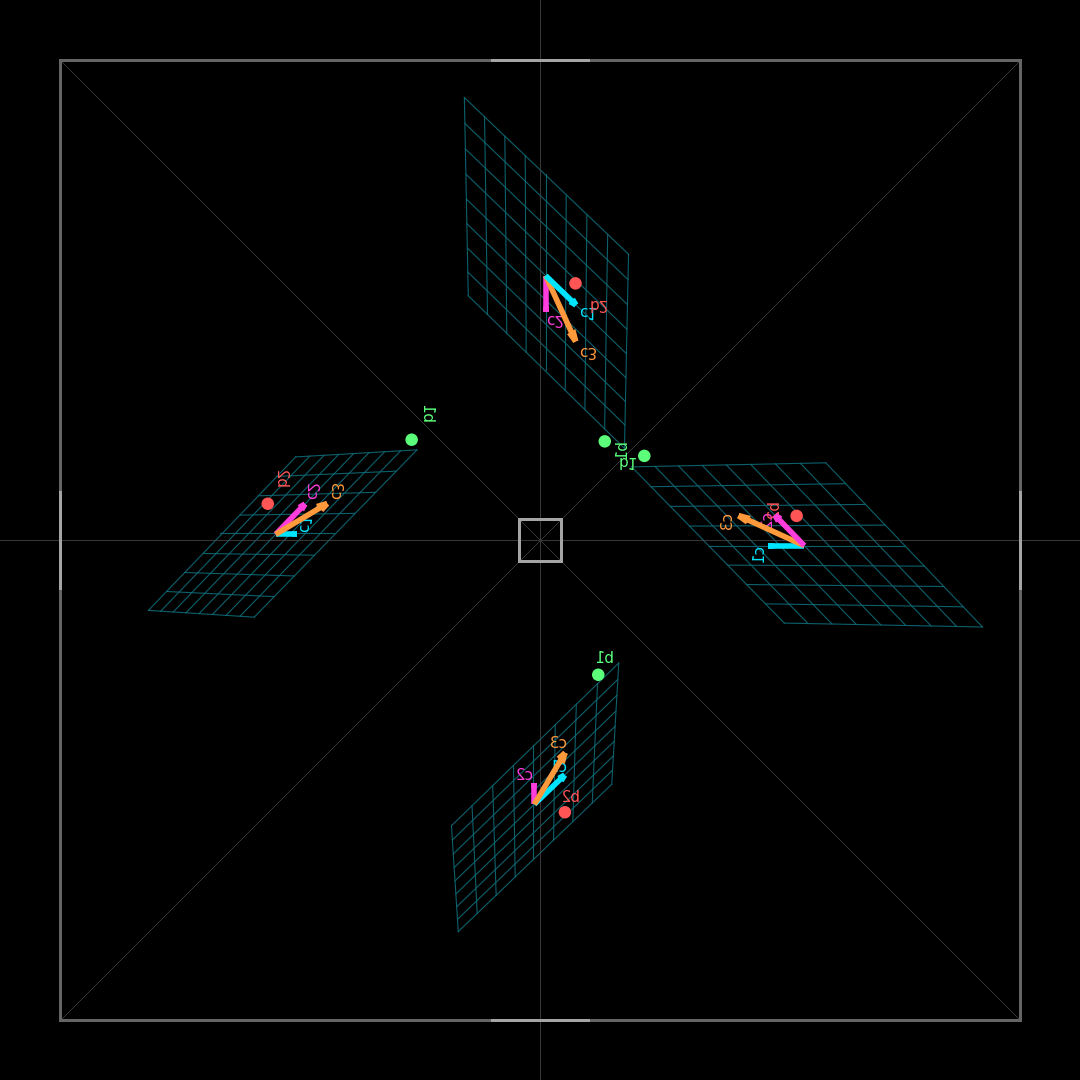

檔案：holo_out/P4_ink_gamut.png   ← 左側『檔案』面板可下載，或用下方 Web 介面推到手機
[ok] holo_out/P4_ink_gamut_spin.mp4  (72 影格 @ 20fps)


檔案：holo_out/P4_ink_gamut_spin.mp4
巡堂追問：如果要調出 b2，我們必須替換掉 c3，新向量在幾何上必須滿足什麼條件？


In [ ]:
#@title P4-2　產生小組破案用的全息投影（靜態圖 + 繞一圈的旋轉影片）
show_png(sc_ink.to_hologram("P4_ink_gamut.png", zoom=1.45))

# 旋轉版：相機繞物件一圈，學生更容易看出 b2 是「懸空」的
play(sc_ink.to_hologram("P4_ink_gamut_spin.mp4", spin=360, n_frames=72, zoom=1.45))

print("巡堂追問：如果要調出 b2，我們必須替換掉 c3，新向量在幾何上必須滿足什麼條件？")

---
# Phase 5 ｜ Evaluate 成效評估（02:35 – 03:00）

## 即時概念測驗（Zuvio / Google 表單）

1. **（概念選擇）** 若矩陣 $A_{3\times3}$ 的 3 個行向量線性相依，則線性方程組 $A\mathbf{x}=\mathbf{b}$ 何者正確？
   (A) 對任意向量 $\mathbf{b}$ 恆有解　(B) 行向量張出整個 3D 空間
   (C) 只有當目標向量 $\mathbf{b}$ 落在特定的 2D 平面（或 1D 線）上時才有解
2. **（簡答題）** 請以幾何觀點解釋：為什麼用行消去法把某個向量消成全零時，代表空間維度沒有增加？

> **教學回饋機制**：若答錯率高於 20%，立即投影下面這支影片——旋轉展示相依向量被壓扁在平面上的空間視角。

In [ ]:
#@title P5-1　回饋用：三根相依向量被「壓扁」在同一張平面上（旋轉展示影片）
sc_flat = (Scene(lim=6)
           .span_plane(a1, a2, color="#0E6B78", rng=1.3, n=9, alpha=0.95)
           .cloud(pts_case1, CYAN, size=2, opacity=0.40)
           .arrow(a1, RED, "a1")
           .arrow(a2, "#4D9BFF", "a2")
           .arrow(a3_case1, YELLOW, "a3 = 2a1+a2")
           .point(b, GREEN, "b"))

play(sc_flat.to_hologram("P5_dependent_flat_spin.mp4",
                         spin=360, n_frames=72, zoom=1.15))
print("旋轉到側面時，三根向量與整片點雲會疊成一條線 —— 這就是『Rank = 2』的視覺證據。")

In [ ]:
#@title P5-2　課堂總結：列出本堂所有投影檔，並重新顯示你的 QR Code
import glob, os
print("本堂已產生的投影檔：")
for f in sorted(glob.glob(os.path.join(OUT_DIR, "*"))):
    print("   ", os.path.basename(f), f"({os.path.getsize(f)//1024} KB)")

print("\n你的個人網址：", URL)
display(qrcode.make(URL).resize((300, 300)))
print("在手機頁面按『↻ 重新整理』就能看到上面所有檔案；或直接 push(檔名) 推到手機。")

---
# 附錄 A ｜ 投影效果校正指南

全息投影看不清楚，幾乎都是下面五件事之一。**開學前務必在 D919 實測一次。**

| 症狀 | 要調的參數 | 怎麼調 |
|---|---|---|
| 影像被金字塔邊緣切掉 | `CFG['zoom']` | 從 1.35 往下調到 1.1 ~ 1.2 |
| 四個影像離中心太遠／太近，對不到金字塔 | `CFG['offset']` | 讓外圍方框剛好對齊底座四邊；金字塔大就調大 |
| 正面看到的字是反的 | `CFG['mirror']` | 改成 `False` 再跑一次 S0-3 校正圖 |
| 繞一圈時畫面跳動、不連續 | `CFG['azim_front']` | ±90 試試 |
| 影像看起來太「俯視」 | `CFG['elev']` | 金字塔是水平看進去的，建議 10 ~ 20 |
| 標籤文字變成一堆方框 □□□ | 標籤內容 | matplotlib 預設字型不含中文。**全息圖上的標籤一律用英數字**（`"a1"`、`"b"`），中文寫在 Plotly 的標題就好 |

改法（改完之後重跑任何一格即可生效）：

```python
CFG['offset'] = 300      # 例：換了比較大的金字塔
CFG['zoom']   = 1.15
CFG['grid_level'] = 0    # 上課時想把對齊格線關掉，設成 0；或 CFG['grid']=False
```

### 教室環境（最大單點風險）

- Pepper's ghost 靠**反射**成像，**暗處等於透明**。所以所有素材一律黑底＋亮色細線，不要用填色面。
- D919 白天開燈狀態下先測一次。若無法充分調暗，備案：拉窗簾／加遮光布／改成小組圍著單支手機看。
- 手機亮度調到最大、關閉自動亮度與自動旋轉、關閉螢幕休眠。

---

# 附錄 B ｜ 學生自己畫任意向量的最小範例

給學生做延伸挑戰（Elaborate）時，把這段貼給他們就夠了：

```python
v1 = [1, 2, 0]        # 改這裡
v2 = [0, 1, 3]        # 改這裡
target = [2, 5, 3]    # 改這裡

sc = (Scene()
      .span_plane(v1, v2, color="#0E6B78")   # 兩向量張成的平面
      .arrow(v1, RED, "v1")
      .arrow(v2, "#4D9BFF", "v2")
      .point(target, GREEN, "b"))
sc.show("我的向量")                           # ① 先在 Colab 旋轉看
sc.to_hologram("我的作品.png")                # ② 再產生金字塔投影圖
```

判斷「有沒有解」：

```python
A = np.column_stack([v1, v2])
print(has_solution(A, target))      # (True/False, rank(A), rank([A|b]))
column_reduce(A)                     # 看行消去的每一步
```

---

# 附錄 C ｜ 下週銜接（Row View）

下週學完列高斯消去法後，同一份 Notebook 只要把 `sc_row`（P3-1）那段的矩陣換掉，
就能直接做「三個平面互相平行 / 帳篷式兩兩相交但無共同交點」的無解幾何展示：

```python
A_no = np.array([[1., 1., 1.],
                 [2., 2., 2.],       # 與第一列平行 → 平面重合或平行
                 [1., -1., 0.]])
rhs  = np.array([1., 5., 0.])        # 2×(第一式) ≠ 第二式 → 無解
s = Scene(lim=4)
for r, d, c in zip(A_no, rhs, [CYAN, MAGENTA, YELLOW]):
    s.plane_eq(r, d, color=c, rng=1.1, n=6, alpha=0.55)
s.show("Row View：無解長什麼樣子")
s.to_hologram("下週_row_no_solution.png")
```